# Laboratorium 7 - Przeplyw Optyczny


## Zadanie 1 - Block Matching

Od tego miejsca zaczyna sie implementacja podstawowej metody block matching: wczytanie klatek, estymacja przeplywu i wizualizacja HSV.


In [25]:
from __future__ import annotations

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def find_sequence_frames(sequence_dir: Path, suffixes: tuple[str, ...] = (".png", ".jpg", ".jpeg", ".bmp")) -> list[Path]:
    frames = [p for p in sorted(sequence_dir.iterdir()) if p.suffix.lower() in suffixes]
    if len(frames) < 2:
        msg = f"Need at least two image frames in: {sequence_dir}"
        raise ValueError(msg)
    return frames


def load_frame_pair(
    *,
    frames: list[Path],
    index_prev: int,
    index_next: int,
    downsample_factor: int = 1,
) -> tuple[np.ndarray, np.ndarray]:
    bgr_prev = cv2.imread(str(frames[index_prev]), cv2.IMREAD_COLOR)
    bgr_next = cv2.imread(str(frames[index_next]), cv2.IMREAD_COLOR)
    if bgr_prev is None or bgr_next is None:
        msg = "Failed to read one of the selected frames."
        raise ValueError(msg)

    gray_prev = cv2.cvtColor(bgr_prev, cv2.COLOR_BGR2GRAY)
    gray_next = cv2.cvtColor(bgr_next, cv2.COLOR_BGR2GRAY)

    if downsample_factor > 1:
        scale = 1.0 / float(downsample_factor)
        gray_prev = cv2.resize(gray_prev, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
        gray_next = cv2.resize(gray_next, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

    return gray_prev, gray_next


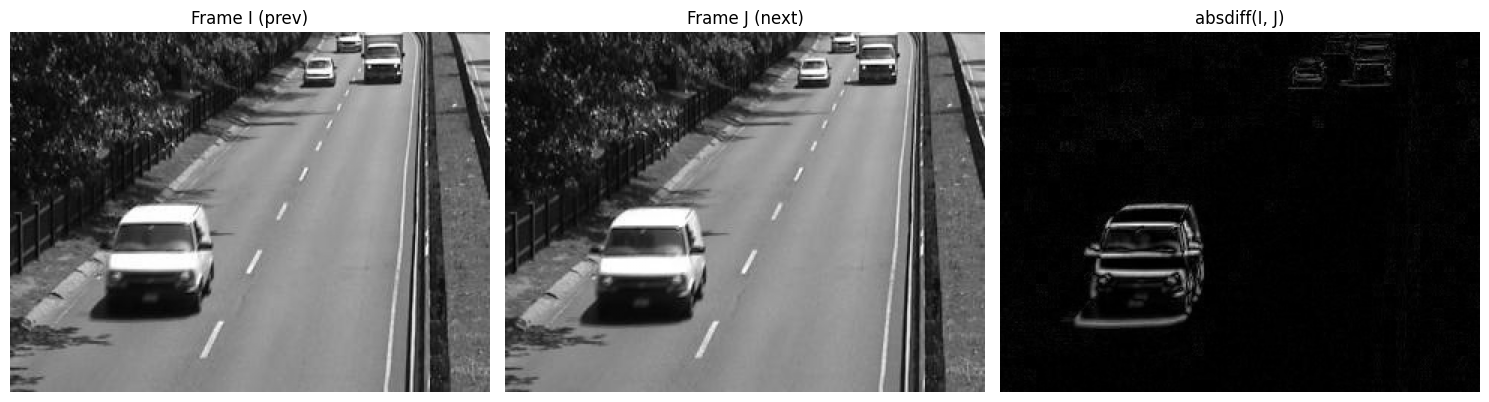

In [26]:
sequence_dir = Path("./data/highway/input")
frame_prev_index = 150
frame_next_index = 151
downsample_factor = 1

frames = find_sequence_frames(sequence_dir=sequence_dir)
I, J = load_frame_pair(  # noqa: E741
    frames=frames,
    index_prev=frame_prev_index,
    index_next=frame_next_index,
    downsample_factor=downsample_factor,
)

diff_abs = cv2.absdiff(I, J)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(I, cmap="gray")
axes[0].set_title("Frame I (prev)")
axes[1].imshow(J, cmap="gray")
axes[1].set_title("Frame J (next)")
axes[2].imshow(diff_abs, cmap="gray")
axes[2].set_title("absdiff(I, J)")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()


In [27]:
def build_motion_mask(
    *,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    threshold: int,
    kernel_size: int,
    iterations: int,
) -> np.ndarray:
    diff = cv2.absdiff(I_gray, J_gray)
    _, binary = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)
    dilated = cv2.dilate(binary, kernel, iterations=iterations)
    return dilated


def block_matching_flow(
    *,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    window_size: int = 7,
    search_x: int = 3,
    search_y: int = 3,
    use_motion_mask: bool = True,
    diff_threshold: int = 20,
    dilate_kernel_size: int = 5,
    dilate_iterations: int = 1,
) -> tuple[np.ndarray, np.ndarray, np.ndarray | None]:
    if window_size % 2 == 0:
        msg = "window_size must be odd (e.g. 7, 9, 11)."
        raise ValueError(msg)

    half_window = window_size // 2
    height, width = I_gray.shape

    u = np.zeros((height, width), dtype=np.float32)
    v = np.zeros((height, width), dtype=np.float32)

    motion_mask: np.ndarray | None = None
    if use_motion_mask:
        motion_mask = build_motion_mask(
            I_gray=I_gray,
            J_gray=J_gray,
            threshold=diff_threshold,
            kernel_size=dilate_kernel_size,
            iterations=dilate_iterations,
        )

    for j in range(half_window, height - half_window):
        for i in range(half_window, width - half_window):
            if motion_mask is not None and motion_mask[j, i] == 0:
                continue

            ref_patch = np.float32(
                I_gray[
                    j - half_window : j + half_window + 1,
                    i - half_window : i + half_window + 1,
                ]
            )

            best_dist = np.inf
            best_di = 0
            best_dj = 0

            for dj in range(-search_y, search_y + 1):
                for di in range(-search_x, search_x + 1):
                    cj = j + dj
                    ci = i + di

                    if (
                        cj - half_window < 0
                        or cj + half_window >= height
                        or ci - half_window < 0
                        or ci + half_window >= width
                    ):
                        continue

                    cand_patch = np.float32(
                        J_gray[
                            cj - half_window : cj + half_window + 1,
                            ci - half_window : ci + half_window + 1,
                        ]
                    )
                    dist = np.sqrt(np.sum(np.square(cand_patch - ref_patch)))

                    if dist < best_dist:
                        best_dist = dist
                        best_di = di
                        best_dj = dj

            u[j, i] = float(best_di)
            v[j, i] = float(best_dj)

    return u, v, motion_mask


In [28]:
def flow_to_bgr_hsv(*, u: np.ndarray, v: np.ndarray, clip_magnitude: float | None = None) -> np.ndarray:
    mag, angle = cv2.cartToPolar(u, v)
    if clip_magnitude is not None:
        mag = np.minimum(mag, np.float32(clip_magnitude))

    hsv = np.zeros((u.shape[0], u.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = np.uint8((angle * 90.0 / np.pi) % 180.0)
    hsv[..., 1] = np.uint8(cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX))
    hsv[..., 2] = 255

    # Swap S and V so zero-motion areas become black.
    hsv[..., [1, 2]] = hsv[..., [2, 1]]
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return bgr


def show_flow_results(
    *,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    u: np.ndarray,
    v: np.ndarray,
    motion_mask: np.ndarray | None,
) -> None:
    flow_bgr = flow_to_bgr_hsv(u=u, v=v)
    flow_rgb = cv2.cvtColor(flow_bgr, cv2.COLOR_BGR2RGB)
    diff = cv2.absdiff(I_gray, J_gray)

    ncols = 4 if motion_mask is not None else 3
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

    axes[0].imshow(I_gray, cmap="gray")
    axes[0].set_title("Frame I")
    axes[1].imshow(J_gray, cmap="gray")
    axes[1].set_title("Frame J")
    axes[2].imshow(flow_rgb)
    axes[2].set_title("Optical Flow (HSV)")

    if motion_mask is not None:
        axes[3].imshow(diff, cmap="gray")
        axes[3].imshow(motion_mask, cmap="jet", alpha=0.35)
        axes[3].set_title("absdiff + motion mask")

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


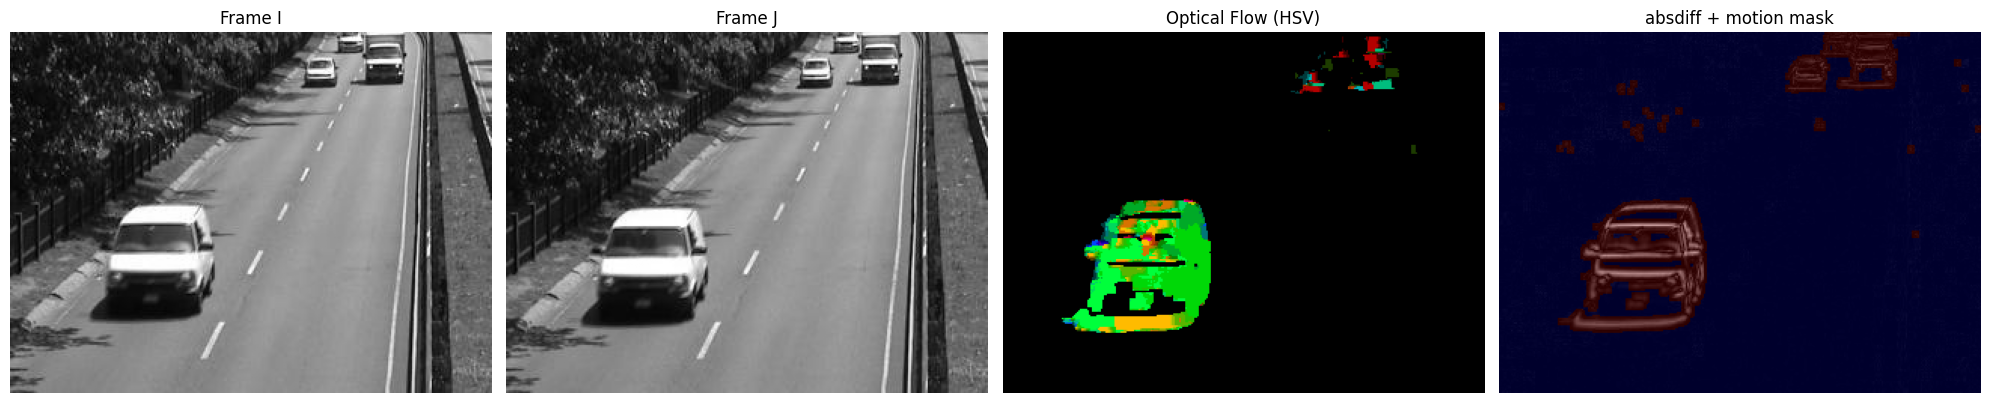

Flow range: u=[-3.0, 3.0], v=[-3.0, 3.0] | window=7, search=(3, 3)


In [29]:
u, v, motion_mask = block_matching_flow(
    I_gray=I,
    J_gray=J,
    window_size=7,
    search_x=3,
    search_y=3,
    use_motion_mask=True,
    diff_threshold=20,
    dilate_kernel_size=5,
    dilate_iterations=1,
)

show_flow_results(
    I_gray=I,
    J_gray=J,
    u=u,
    v=v,
    motion_mask=motion_mask,
)

print(
    f"Flow range: u=[{u.min():.1f}, {u.max():.1f}], v=[{v.min():.1f}, {v.max():.1f}] | "
    "window=7, search=(3, 3)"
)


## Zadanie 2 - Wersja wieloskalowa (piramidalna)

Od tego miejsca zaczyna sie implementacja metody coarse-to-fine: piramida obrazow, warping i akumulacja przeplywu.


In [30]:
from time import perf_counter


def of(
    *,
    J_org: np.ndarray,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    W2: int = 3,
    dY: int = 3,
    dX: int = 3,
    use_motion_mask: bool = True,
    diff_threshold: int = 20,
    dilate_kernel_size: int = 5,
    dilate_iterations: int = 1,
) -> tuple[np.ndarray, np.ndarray]:
    del J_org  # kept for compatibility with the task signature
    window_size = 2 * W2 + 1
    u, v, _ = block_matching_flow(
        I_gray=I_gray,
        J_gray=J_gray,
        window_size=window_size,
        search_x=dX,
        search_y=dY,
        use_motion_mask=use_motion_mask,
        diff_threshold=diff_threshold,
        dilate_kernel_size=dilate_kernel_size,
        dilate_iterations=dilate_iterations,
    )
    return u, v


def vis_flow(*, u: np.ndarray, v: np.ndarray, YX: tuple[int, int], name: str) -> None:
    del YX
    flow_bgr = flow_to_bgr_hsv(u=u, v=v)
    flow_rgb = cv2.cvtColor(flow_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 5))
    plt.imshow(flow_rgb)
    plt.title(name)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def pyramid(*, im: np.ndarray, max_scale: int) -> list[np.ndarray]:
    images = [im]
    for _ in range(1, max_scale):
        images.append(
            cv2.resize(images[-1], (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
        )
    return images


def resize_flow_to_shape(
    *,
    u: np.ndarray,
    v: np.ndarray,
    target_shape: tuple[int, int],
) -> tuple[np.ndarray, np.ndarray]:
    target_h, target_w = target_shape
    src_h, src_w = u.shape
    scale_x = target_w / src_w
    scale_y = target_h / src_h

    u_resized = cv2.resize(u, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    v_resized = cv2.resize(v, (target_w, target_h), interpolation=cv2.INTER_LINEAR)

    u_scaled = np.float32(u_resized * scale_x)
    v_scaled = np.float32(v_resized * scale_y)
    return u_scaled, v_scaled


def warp_image_with_flow_integer(
    *,
    image: np.ndarray,
    u: np.ndarray,
    v: np.ndarray,
) -> np.ndarray:
    height, width = image.shape
    warped = np.copy(image)

    for j in range(height):
        for i in range(width):
            src_j = int(round(j + v[j, i]))
            src_i = int(round(i + u[j, i]))
            if 0 <= src_j < height and 0 <= src_i < width:
                warped[j, i] = image[src_j, src_i]

    return warped


In [31]:
def multiscale_block_matching_flow(
    *,
    I_gray: np.ndarray,
    J_gray: np.ndarray,
    max_scale: int = 3,
    W2: int = 3,
    dX: int = 3,
    dY: int = 3,
    use_motion_mask: bool = True,
    diff_threshold: int = 20,
    dilate_kernel_size: int = 5,
    dilate_iterations: int = 1,
    show_scale_debug: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    IP = pyramid(im=I_gray, max_scale=max_scale)
    JP = pyramid(im=J_gray, max_scale=max_scale)

    U = np.zeros(I_gray.shape, dtype=np.float32)
    V = np.zeros(I_gray.shape, dtype=np.float32)

    J_current = JP[-1]

    for s in range(max_scale - 1, -1, -1):
        I_level = IP[s]

        if J_current.shape != I_level.shape:
            J_current = cv2.resize(
                J_current,
                (I_level.shape[1], I_level.shape[0]),
                interpolation=cv2.INTER_LINEAR,
            )

        u_level, v_level = of(
            J_org=JP[s],
            I_gray=I_level,
            J_gray=J_current,
            W2=W2,
            dY=dY,
            dX=dX,
            use_motion_mask=use_motion_mask,
            diff_threshold=diff_threshold,
            dilate_kernel_size=dilate_kernel_size,
            dilate_iterations=dilate_iterations,
        )

        u_full, v_full = resize_flow_to_shape(
            u=u_level,
            v=v_level,
            target_shape=I_gray.shape,
        )
        U += u_full
        V += v_full

        if show_scale_debug:
            vis_flow(
                u=u_level,
                v=v_level,
                YX=I_level.shape,
                name=f"Flow at scale {s}",
            )

        if s > 0:
            next_shape = IP[s - 1].shape
            u_next, v_next = resize_flow_to_shape(
                u=u_level,
                v=v_level,
                target_shape=next_shape,
            )

            J_next_original = JP[s - 1]
            J_current = warp_image_with_flow_integer(
                image=J_next_original,
                u=u_next,
                v=v_next,
            )

    return U, V


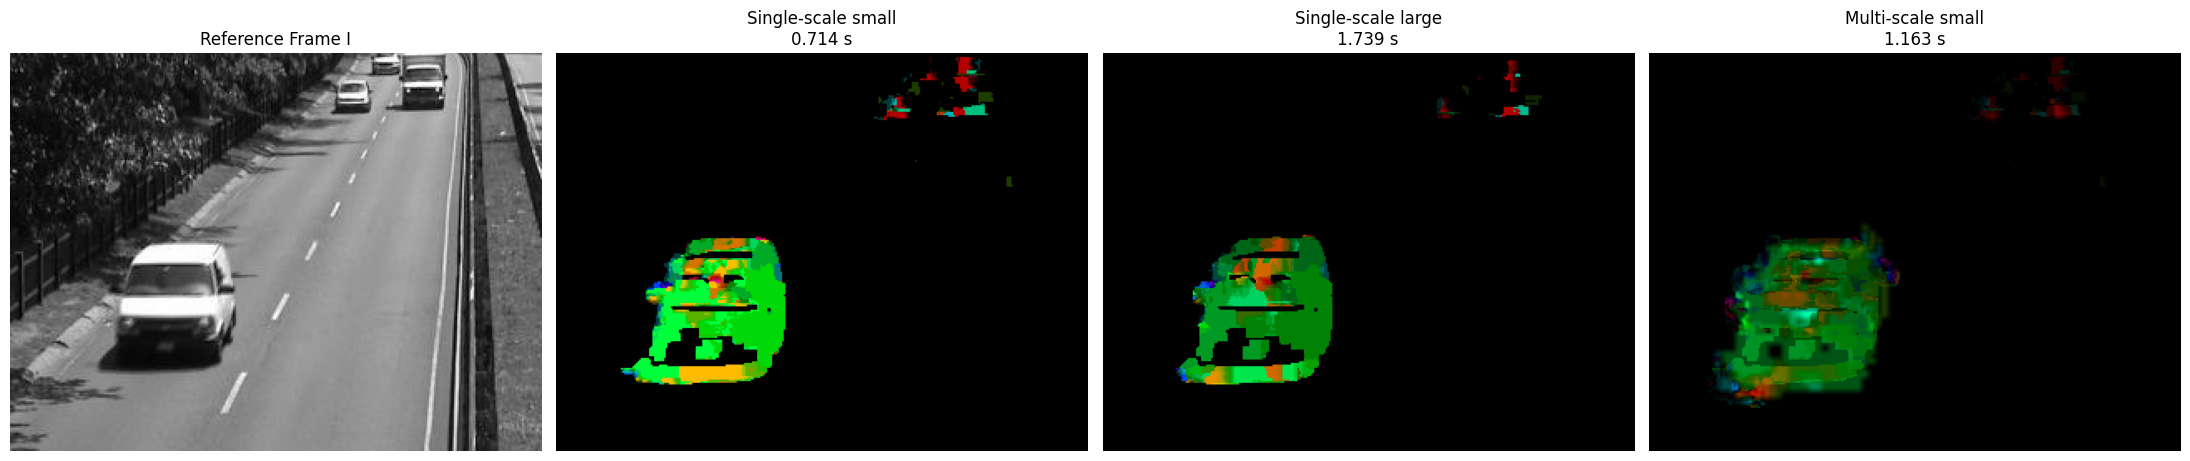

Runtime summary:
single-scale small: 0.714 s
single-scale large: 1.739 s
multi-scale small:  1.163 s


In [32]:
single_small_kwargs = dict(
    I_gray=I,
    J_gray=J,
    window_size=7,
    search_x=3,
    search_y=3,
    use_motion_mask=True,
    diff_threshold=20,
    dilate_kernel_size=5,
    dilate_iterations=1,
)

single_large_kwargs = dict(
    I_gray=I,
    J_gray=J,
    window_size=11,
    search_x=5,
    search_y=5,
    use_motion_mask=True,
    diff_threshold=20,
    dilate_kernel_size=5,
    dilate_iterations=1,
)

multi_kwargs = dict(
    I_gray=I,
    J_gray=J,
    max_scale=3,
    W2=3,
    dX=3,
    dY=3,
    use_motion_mask=True,
    diff_threshold=20,
    dilate_kernel_size=5,
    dilate_iterations=1,
    show_scale_debug=False,
)

start = perf_counter()
u_small, v_small, _ = block_matching_flow(**single_small_kwargs)
t_small = perf_counter() - start

start = perf_counter()
u_large, v_large, _ = block_matching_flow(**single_large_kwargs)
t_large = perf_counter() - start

start = perf_counter()
U_multi, V_multi = multiscale_block_matching_flow(**multi_kwargs)
t_multi = perf_counter() - start

flow_small_rgb = cv2.cvtColor(flow_to_bgr_hsv(u=u_small, v=v_small), cv2.COLOR_BGR2RGB)
flow_large_rgb = cv2.cvtColor(flow_to_bgr_hsv(u=u_large, v=v_large), cv2.COLOR_BGR2RGB)
flow_multi_rgb = cv2.cvtColor(flow_to_bgr_hsv(u=U_multi, v=V_multi), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(I, cmap="gray")
axes[0].set_title("Reference Frame I")
axes[1].imshow(flow_small_rgb)
axes[1].set_title(f"Single-scale small\n{t_small:.3f} s")
axes[2].imshow(flow_large_rgb)
axes[2].set_title(f"Single-scale large\n{t_large:.3f} s")
axes[3].imshow(flow_multi_rgb)
axes[3].set_title(f"Multi-scale small\n{t_multi:.3f} s")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

print("Runtime summary:")
print(f"single-scale small: {t_small:.3f} s")
print(f"single-scale large: {t_large:.3f} s")
print(f"multi-scale small:  {t_multi:.3f} s")


## Zadanie 3 - Metody OpenCV (geste i rzadkie)

Ponizej porownanie gotowych metod OpenCV dla przeplywu optycznego. Implementacja zawiera:
- parametr `iStep` do wyboru co ktora klatke analizowac,
- metody geste (Farneback, Dual TV-L1, PCA Flow, DIS, Simple Flow, Deep Flow, dense LK),
- metode rzadka Lucas-Kanade na regularnej siatce punktow.


In [33]:
from collections.abc import Callable
from typing import Any


def iterate_frame_pairs(
    *,
    frame_paths: list[Path],
    start_index: int,
    end_index: int | None = None,
    iStep: int = 1,
    max_pairs: int | None = None,
) -> list[tuple[int, int]]:
    if iStep < 1:
        msg = "iStep must be >= 1"
        raise ValueError(msg)

    last_valid = len(frame_paths) - iStep - 1
    if last_valid < start_index:
        return []

    if end_index is None:
        end_index = len(frame_paths) - iStep - 1

    end_index = min(end_index, len(frame_paths) - iStep - 1)
    pairs: list[tuple[int, int]] = []

    for idx in range(start_index, end_index + 1, iStep):
        pairs.append((idx, idx + iStep))
        if max_pairs is not None and len(pairs) >= max_pairs:
            break

    return pairs


def create_dense_flow_factories() -> dict[str, Callable[[], Any]]:
    factories: dict[str, Callable[[], Any]] = {}

    if hasattr(cv2, "FarnebackOpticalFlow_create"):
        factories["Farneback"] = cv2.FarnebackOpticalFlow_create

    if hasattr(cv2, "optflow") and hasattr(cv2.optflow, "createOptFlow_DualTVL1"):
        factories["Dual TV-L1"] = cv2.optflow.createOptFlow_DualTVL1

    if hasattr(cv2, "optflow") and hasattr(cv2.optflow, "createOptFlow_PCAFlow"):
        factories["PCA Flow"] = cv2.optflow.createOptFlow_PCAFlow

    if hasattr(cv2, "DISOpticalFlow_create"):
        factories["DIS Flow"] = lambda: cv2.DISOpticalFlow_create(cv2.DISOPTICAL_FLOW_PRESET_MEDIUM)
    elif hasattr(cv2, "optflow") and hasattr(cv2.optflow, "createOptFlow_DIS"):
        factories["DIS Flow"] = cv2.optflow.createOptFlow_DIS

    if hasattr(cv2, "optflow") and hasattr(cv2.optflow, "createOptFlow_SimpleFlow"):
        factories["Simple Flow"] = cv2.optflow.createOptFlow_SimpleFlow

    if hasattr(cv2, "optflow") and hasattr(cv2.optflow, "createOptFlow_DeepFlow"):
        factories["Deep Flow"] = cv2.optflow.createOptFlow_DeepFlow

    return factories


def run_dense_method(
    *,
    method_name: str,
    prev_gray: np.ndarray,
    next_gray: np.ndarray,
    dense_factories: dict[str, Callable[[], Any]],
) -> tuple[np.ndarray, np.ndarray]:
    if method_name == "Dense LK":
        if not hasattr(cv2, "optflow") or not hasattr(cv2.optflow, "calcOpticalFlowSparseToDense"):
            msg = "Dense LK (SparseToDense) is not available in this OpenCV build."
            raise RuntimeError(msg)
        flow = cv2.optflow.calcOpticalFlowSparseToDense(prev_gray, next_gray, None)
        return np.float32(flow[..., 0]), np.float32(flow[..., 1])

    if method_name not in dense_factories:
        msg = f"Method not available: {method_name}"
        raise RuntimeError(msg)

    estimator = dense_factories[method_name]()
    flow = np.zeros((prev_gray.shape[0], prev_gray.shape[1], 2), dtype=np.float32)
    flow = estimator.calc(prev_gray, next_gray, flow)
    return np.float32(flow[..., 0]), np.float32(flow[..., 1])


def compute_flow_quality_metrics(*, prev_gray: np.ndarray, u: np.ndarray, v: np.ndarray) -> dict[str, float]:
    mag, _ = cv2.cartToPolar(u, v)
    edges = cv2.Canny(prev_gray, 80, 160) > 0

    lap = np.abs(cv2.Laplacian(prev_gray, cv2.CV_32F))
    texture_threshold = float(np.percentile(lap, 25.0))
    uniform = lap <= texture_threshold

    edge_motion_mean = float(mag[edges].mean()) if np.any(edges) else float("nan")
    uniform_motion_mean = float(mag[uniform].mean()) if np.any(uniform) else float("nan")

    ratio = float("nan")
    if np.isfinite(uniform_motion_mean) and uniform_motion_mean > 1e-6:
        ratio = float(edge_motion_mean / uniform_motion_mean)

    return {
        "edge_motion_mean": edge_motion_mean,
        "uniform_motion_mean": uniform_motion_mean,
        "edge_uniform_ratio": ratio,
    }


def compare_dense_methods_on_pairs(
    *,
    frame_paths: list[Path],
    pairs: list[tuple[int, int]],
    downsample_factor: int = 1,
    dense_method_order: list[str] | None = None,
) -> tuple[list[dict[str, Any]], dict[str, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]]:
    dense_factories = create_dense_flow_factories()

    if dense_method_order is None:
        dense_method_order = [
            "Farneback",
            "Dual TV-L1",
            "PCA Flow",
            "DIS Flow",
            "Simple Flow",
            "Deep Flow",
            "Dense LK",
        ]

    rows: list[dict[str, Any]] = []
    sample_visualizations: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]] = {}

    for pair_index, (idx_prev, idx_next) in enumerate(pairs):
        prev_gray, next_gray = load_frame_pair(
            frames=frame_paths,
            index_prev=idx_prev,
            index_next=idx_next,
            downsample_factor=downsample_factor,
        )

        for method_name in dense_method_order:
            start = perf_counter()
            try:
                u, v = run_dense_method(
                    method_name=method_name,
                    prev_gray=prev_gray,
                    next_gray=next_gray,
                    dense_factories=dense_factories,
                )
                runtime_ms = (perf_counter() - start) * 1000.0
                available = True
                error_message = ""

                metrics = compute_flow_quality_metrics(prev_gray=prev_gray, u=u, v=v)

                if pair_index == 0:
                    sample_visualizations[method_name] = (prev_gray, next_gray, u, v)

            except Exception as error:  # noqa: BLE001
                runtime_ms = (perf_counter() - start) * 1000.0
                available = False
                error_message = str(error)
                metrics = {
                    "edge_motion_mean": float("nan"),
                    "uniform_motion_mean": float("nan"),
                    "edge_uniform_ratio": float("nan"),
                }

            rows.append(
                {
                    "method": method_name,
                    "pair": f"{idx_prev}->{idx_next}",
                    "runtime_ms": runtime_ms,
                    "available": available,
                    "edge_motion_mean": metrics["edge_motion_mean"],
                    "uniform_motion_mean": metrics["uniform_motion_mean"],
                    "edge_uniform_ratio": metrics["edge_uniform_ratio"],
                    "error": error_message,
                }
            )

    return rows, sample_visualizations


def summarize_dense_results(*, rows: list[dict[str, Any]]) -> list[dict[str, Any]]:
    aggregates: dict[str, dict[str, Any]] = {}

    for row in rows:
        if not bool(row["available"]):
            continue

        method = str(row["method"])
        if method not in aggregates:
            aggregates[method] = {
                "method": method,
                "count": 0,
                "runtime_ms": 0.0,
                "edge_motion_mean": 0.0,
                "uniform_motion_mean": 0.0,
                "edge_uniform_ratio": 0.0,
            }

        aggregates[method]["count"] += 1
        aggregates[method]["runtime_ms"] += float(row["runtime_ms"])
        aggregates[method]["edge_motion_mean"] += float(row["edge_motion_mean"])
        aggregates[method]["uniform_motion_mean"] += float(row["uniform_motion_mean"])
        aggregates[method]["edge_uniform_ratio"] += float(row["edge_uniform_ratio"])

    summary: list[dict[str, Any]] = []
    for method, agg in aggregates.items():
        count = int(agg["count"])
        summary.append(
            {
                "method": method,
                "runtime_ms": agg["runtime_ms"] / count,
                "edge_motion_mean": agg["edge_motion_mean"] / count,
                "uniform_motion_mean": agg["uniform_motion_mean"] / count,
                "edge_uniform_ratio": agg["edge_uniform_ratio"] / count,
            }
        )

    summary.sort(key=lambda item: float(item["runtime_ms"]))
    return summary


def print_dense_summary(*, summary: list[dict[str, Any]]) -> None:
    if len(summary) == 0:
        print("No available dense methods to summarize.")
        return

    header = (
        f"{'method':<14} {'runtime_ms':>11} {'edge_mean':>11} "
        f"{'uniform_mean':>13} {'edge/uniform':>13}"
    )
    print(header)
    print("-" * len(header))

    for item in summary:
        print(
            f"{item['method']:<14} "
            f"{item['runtime_ms']:>11.2f} "
            f"{item['edge_motion_mean']:>11.3f} "
            f"{item['uniform_motion_mean']:>13.3f} "
            f"{item['edge_uniform_ratio']:>13.3f}"
        )


In [34]:
task3_sequence_dir = Path("./data/highway/input")
task3_start_index = 150
task3_end_index = 154
task3_iStep = 1
task3_max_pairs = 2
task3_downsample_factor = 1

task3_frames = find_sequence_frames(sequence_dir=task3_sequence_dir)
task3_pairs = iterate_frame_pairs(
    frame_paths=task3_frames,
    start_index=task3_start_index,
    end_index=task3_end_index,
    iStep=task3_iStep,
    max_pairs=task3_max_pairs,
)

if len(task3_pairs) == 0:
    raise ValueError("No frame pairs selected. Adjust start/end/iStep parameters.")

dense_rows, dense_visual_cache = compare_dense_methods_on_pairs(
    frame_paths=task3_frames,
    pairs=task3_pairs,
    downsample_factor=task3_downsample_factor,
)

summary_rows = summarize_dense_results(rows=dense_rows)
print_dense_summary(summary=summary_rows)

unavailable_rows = [row for row in dense_rows if not bool(row["available"]) ]
if len(unavailable_rows) > 0:
    print("\nUnavailable methods in this OpenCV build:")
    seen: set[str] = set()
    for row in unavailable_rows:
        method = str(row["method"])
        if method in seen:
            continue
        seen.add(method)
        print(f"- {method}: {row['error']}")


method          runtime_ms   edge_mean  uniform_mean  edge/uniform
------------------------------------------------------------------
DIS Flow              6.35       0.397         0.550         0.727
Farneback            15.43       0.434         0.438         0.998

Unavailable methods in this OpenCV build:
- Dual TV-L1: Method not available: Dual TV-L1
- PCA Flow: Method not available: PCA Flow
- Simple Flow: Method not available: Simple Flow
- Deep Flow: Method not available: Deep Flow
- Dense LK: Dense LK (SparseToDense) is not available in this OpenCV build.


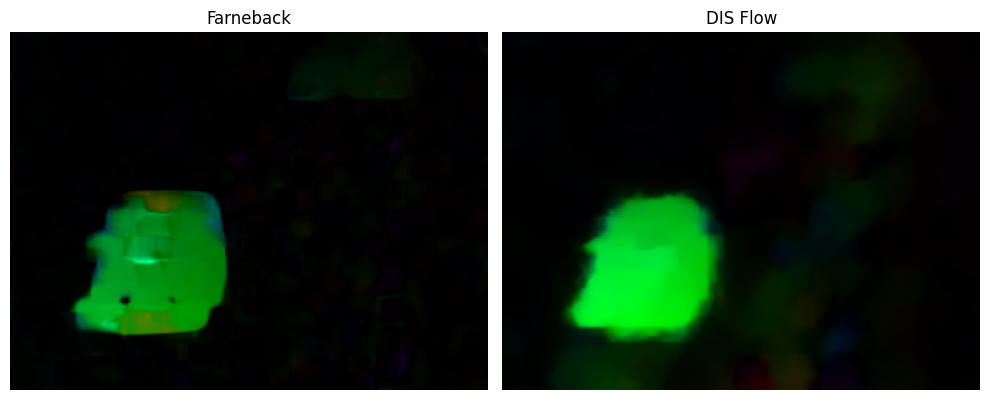

In [35]:
methods_to_show = [
    "Farneback",
    "Dual TV-L1",
    "PCA Flow",
    "DIS Flow",
    "Simple Flow",
    "Deep Flow",
    "Dense LK",
]

available_methods_to_show = [name for name in methods_to_show if name in dense_visual_cache]
n_methods = len(available_methods_to_show)

if n_methods == 0:
    raise RuntimeError("No dense optical-flow methods available for visualization.")

fig, axes = plt.subplots(1, n_methods, figsize=(5 * n_methods, 5))
if n_methods == 1:
    axes = [axes]

for axis, method_name in zip(axes, available_methods_to_show):
    _, _, u_dense, v_dense = dense_visual_cache[method_name]
    clip_value = 10.0 if method_name == "Dense LK" else None
    rgb = cv2.cvtColor(
        flow_to_bgr_hsv(u=u_dense, v=v_dense, clip_magnitude=clip_value),
        cv2.COLOR_BGR2RGB,
    )
    axis.imshow(rgb)
    axis.set_title(method_name)
    axis.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
def create_regular_grid_points(*, image_shape: tuple[int, int], spacing: int = 10) -> np.ndarray:
    height, width = image_shape
    yy, xx = np.mgrid[0:height:spacing, 0:width:spacing]
    points = np.stack((xx.ravel(), yy.ravel()), axis=-1).astype(np.float32)
    return points.reshape(-1, 1, 2)


def draw_sparse_lk_tracks(
    *,
    prev_gray: np.ndarray,
    next_gray: np.ndarray,
    points_prev: np.ndarray,
    min_magnitude: float = 0.0,
    win_size: tuple[int, int] = (15, 15),
    max_level: int = 2,
    max_iter: int = 10,
    epsilon: float = 0.03,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, max_iter, epsilon)

    next_initial = points_prev.copy()
    points_next, st, err = cv2.calcOpticalFlowPyrLK(
        prev_gray,
        next_gray,
        points_prev,
        next_initial,
        winSize=win_size,
        maxLevel=max_level,
        criteria=criteria,
    )

    if points_next is None or st is None or err is None:
        msg = "calcOpticalFlowPyrLK returned no points."
        raise RuntimeError(msg)

    vis = cv2.cvtColor(next_gray, cv2.COLOR_GRAY2BGR)

    for jj in range(points_prev.shape[0]):
        if st[jj, 0] != 1:
            continue

        p0 = points_prev[jj, 0]
        p1 = points_next[jj, 0]

        dx = float(p1[0] - p0[0])
        dy = float(p1[1] - p0[1])
        magnitude = float(np.sqrt(dx * dx + dy * dy))
        if magnitude < min_magnitude:
            continue

        x0, y0 = int(round(p0[0])), int(round(p0[1]))
        x1, y1 = int(round(p1[0])), int(round(p1[1]))

        cv2.line(vis, (x0, y0), (x1, y1), (0, 0, 255), 1, cv2.LINE_AA)
        cv2.circle(vis, (x1, y1), 1, (0, 255, 0), -1, cv2.LINE_AA)

    return vis, points_next, st, err


def run_sparse_lk_on_pairs(
    *,
    frame_paths: list[Path],
    pairs: list[tuple[int, int]],
    downsample_factor: int = 1,
    spacing: int = 10,
    min_magnitude: float = 0.2,
    win_size: tuple[int, int] = (15, 15),
    max_level: int = 2,
    max_iter: int = 10,
    epsilon: float = 0.03,
) -> tuple[list[dict[str, float | int | str]], np.ndarray]:
    rows: list[dict[str, float | int | str]] = []
    last_vis: np.ndarray | None = None

    for idx_prev, idx_next in pairs:
        prev_gray, next_gray = load_frame_pair(
            frames=frame_paths,
            index_prev=idx_prev,
            index_next=idx_next,
            downsample_factor=downsample_factor,
        )

        points_prev = create_regular_grid_points(image_shape=prev_gray.shape, spacing=spacing)

        start = perf_counter()
        vis_bgr, points_next, st, _ = draw_sparse_lk_tracks(
            prev_gray=prev_gray,
            next_gray=next_gray,
            points_prev=points_prev,
            min_magnitude=min_magnitude,
            win_size=win_size,
            max_level=max_level,
            max_iter=max_iter,
            epsilon=epsilon,
        )
        runtime_ms = (perf_counter() - start) * 1000.0

        good = st[:, 0] == 1
        tracked_count = int(good.sum())

        if tracked_count > 0:
            delta = points_next[good, 0] - points_prev[good, 0]
            mean_mag = float(np.linalg.norm(delta, axis=1).mean())
        else:
            mean_mag = float("nan")

        rows.append(
            {
                "pair": f"{idx_prev}->{idx_next}",
                "runtime_ms": runtime_ms,
                "tracked_points": tracked_count,
                "all_points": int(points_prev.shape[0]),
                "mean_magnitude": mean_mag,
            }
        )

        last_vis = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)

    if last_vis is None:
        msg = "No sparse LK visualization generated."
        raise RuntimeError(msg)

    return rows, last_vis


def print_sparse_summary(*, rows: list[dict[str, float | int | str]]) -> None:
    header = f"{'pair':<12} {'runtime_ms':>11} {'tracked':>9} {'all':>7} {'mean_mag':>10}"
    print(header)
    print("-" * len(header))
    for row in rows:
        print(
            f"{str(row['pair']):<12} {float(row['runtime_ms']):>11.2f} "
            f"{int(row['tracked_points']):>9} {int(row['all_points']):>7} {float(row['mean_magnitude']):>10.3f}"
        )


pair          runtime_ms   tracked     all   mean_mag
-----------------------------------------------------
150->151            4.20       768     768      0.629
151->152            3.78       768     768      0.686


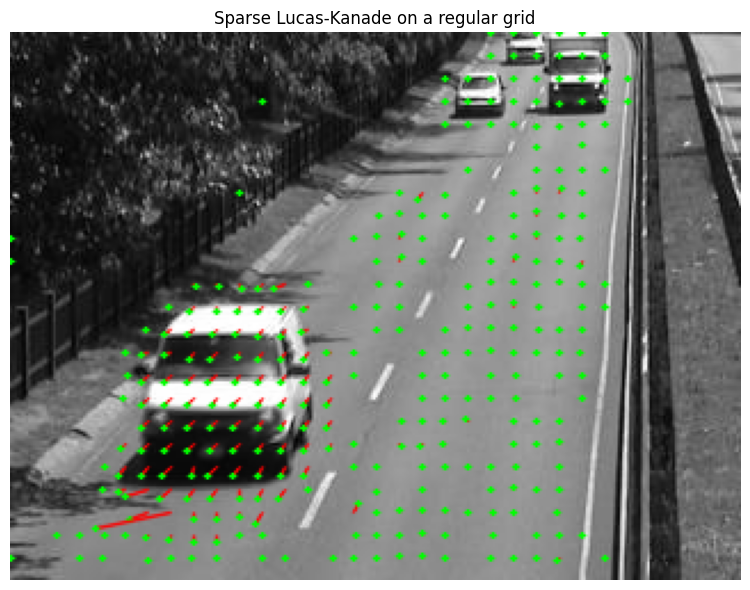

In [37]:
sparse_rows, sparse_vis_rgb = run_sparse_lk_on_pairs(
    frame_paths=task3_frames,
    pairs=task3_pairs,
    downsample_factor=task3_downsample_factor,
    spacing=10,
    min_magnitude=0.2,
    win_size=(15, 15),
    max_level=2,
    max_iter=10,
    epsilon=0.03,
)

print_sparse_summary(rows=sparse_rows)

plt.figure(figsize=(10, 6))
plt.imshow(sparse_vis_rgb)
plt.title("Sparse Lucas-Kanade on a regular grid")
plt.axis("off")
plt.tight_layout()
plt.show()
